# 💉 VaccineNLP · PhoBERT-v2 Multitask Classifier
## Phát hiện Tin giả Vắc-xin & Phân tích Thái độ Cộng đồng (Tiếng Việt)

**Tác giả:** Kim Mạnh Hưng (2211090016) · Đinh Lê Quỳnh Phương (2211090031)  
**Người hướng dẫn:** TS. Trần Lâm Quân  
**Trường:** Đại học Y tế Công cộng (HUPH)  
**Môi trường:** Kaggle · GPU T4 x1  

---

### Tổng quan kiến trúc

Notebook này huấn luyện **Động cơ Phân loại** (Discriminator) trong kiến trúc **Dual-Student Hybrid** của dự án VaccineNLP.
Mô hình sử dụng **PhoBERT-base-v2** (`vinai/phobert-base-v2`) — pretrained encoder tiếng Việt mạnh nhất hiện tại — 
kết hợp với **Multi-task Learning** để dự đoán đồng thời 3 trục phân loại:

| Task | Nhãn | Lý do quan trọng |
|---|---|---|
| **Misinformation** | Không liên quan / Tin giả / Chính xác | Mục tiêu chính của đề tài |
| **Stance** | Ủng hộ / Phản đối / Trung lập / Không rõ | 4 nhãn — Fallback Bucket cho edge cases |
| **Sentiment** | Tiêu cực / Trung tính / Tích cực | Hỗ trợ phân tích thái độ cộng đồng |

### Các quyết định thiết kế then chốt

- **Weighted CrossEntropyLoss**: Bắt buộc do mất cân bằng nhãn nghiêm trọng (class imbalance). Nhãn *Tin giả* chỉ chiếm ~15% corpus.
- **Multi-task Learning (3 heads)**: Chia sẻ encoder giúp regularization tự nhiên, tránh overfitting trên tập nhỏ.
- **Word Segmentation (underthesea)**: PhoBERT yêu cầu văn bản được tách từ tiếng Việt trước khi tokenize.
- **Early Stopping + OneCycleLR**: Tối ưu cho fine-tuning BERT trên GPU đơn.

```
Input Text (đã tách từ)
      ↓
  [PhoBERT Encoder - 110M params]
      ↓
  [CLS] pooler_output (768-dim)
      ↓           ↓           ↓
 Head: Misinfo  Head: Stance  Head: Sentiment
  (3 classes)   (4 classes)   (3 classes)
```

## ⚡ Quick Start — Cấu hình Trước Khi Chạy

> **Chỉ cần sửa 2 dòng dưới đây**, toàn bộ notebook sẽ chạy đúng.

### Bước 1 · Thêm Dataset vào Notebook
Trong Kaggle sidebar → **+ Add Data** → tìm dataset của bạn → Add.  
Sau khi add, đường dẫn sẽ có dạng: `/kaggle/input/<tên-dataset>/...`

### Bước 2 · Cập nhật Paths (Cell Section 3)
```python
TRAIN_PATH = "/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg.jsonl"
TEST_PATH  = "/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl"
```

### Bước 3 · Bật GPU
Kaggle sidebar → **Session options** → Accelerator → **GPU T4 x1** → Save.

### Bước 4 · Chạy All
**Run All** (Shift+Enter từng cell, hoặc menu **Run > Run All Cells**).

---

### Cấu trúc file dữ liệu cần có
```
/kaggle/input/<dataset>/
    ├── 05_model_ready/
    │   └── train_v2_seg.jsonl      ← Training data (đã word-segment)
    └── 03_processed/
        └── benchmark_test_set.jsonl ← Gold Test Set (186 mẫu)
```

### Cấu trúc mỗi dòng JSONL
```json
{"text_segmented": "vắc xin Pfizer an_toàn cho trẻ_em",
 "standardized_ids": [2, 0, 2]}
```
*(standardized_ids = [misinfo_id, stance_id, sentiment_id])*


## 1. Cài đặt Môi trường

Kaggle đã pre-install `torch` và `transformers` với CUDA — **không upgrade** để tránh conflict.  
Chỉ cần cài thêm `underthesea` cho word segmentation tiếng Việt.


In [1]:
# Kaggle pre-installs torch + transformers với CUDA — KHÔNG upgrade
import torch
print(f"PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")

import transformers
print(f"Transformers: {transformers.__version__}")

# underthesea: word segmentation tiếng Việt (bắt buộc cho PhoBERT)
%pip install -q underthesea
print("✅ Setup hoàn tất!")


PyTorch: 2.10.0+cu128 | CUDA: 12.8
Transformers: 5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ Setup hoàn tất!


## 2. Import Thư viện & Cấu hình GPU

Kiểm tra GPU khả dụng. Notebook được thiết kế cho **Kaggle T4 GPU**.


In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'
print(f"✅ Device: {DEVICE} | {gpu_name}")


✅ Device: cuda | Tesla T4


## 3. Cấu hình Thực nghiệm (Hyperparameters)

Tất cả hyperparameter được tập trung tại một cell duy nhất để đảm bảo **reproducibility**.  

**Lưu ý thiết kế:**
- `TASK_WEIGHTS = [0.5, 0.3, 0.2]`: Misinformation được ưu tiên cao nhất vì là mục tiêu chính của đề tài.
- `N_CLASSES['stance'] = 4`: **Hard constraint** — Nhãn thứ 4 (`Không rõ`) là *Fallback Bucket* cho các trường hợp LLM không thể phân loại rõ ràng. Không được đổi thành 3.
- `PATIENCE = 3`: Early stopping ngăn overfitting trên tập Silver Labels có nhiễu LLM (~2%).


In [3]:
# [CELL 3] CẤU HÌNH TẬP TRUNG — PHOBERT
import os
MODEL_NAME = "vinai/phobert-base-v2"
TRAIN_PATH = "/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl"
TEST_PATH  = "/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl"
SAVE_DIR   = "/kaggle/working/phobert_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Hyperparameters ─────────────────────────────────────────────────────────
MAX_LEN      = 256
BATCH_SIZE   = 16
LR           = 2e-5
EPOCHS       = 10
PATIENCE     = 3
SEED         = 42
TASK_WEIGHTS = [0.5, 0.3, 0.2]

# ── Taxonomy (HARD CONSTRAINT) ───────────────────────────────────────────
# ── Taxonomy v3 (HARD CONSTRAINT) ────────────────────────────────────────
N_CLASSES = {"misinfo": 2, "stance": 3, "sentiment": 3}
LABEL_NAMES = {
    "misinfo":   ["Tin giả",   "Chính xác"],
    "stance":    ["Ủng hộ",    "Phản đối",   "Trung lập"],
    "sentiment": ["Tiêu cực",  "Trung tính",  "Tích cực"],
}
MISINFO_MAP   = {0: "Tin giả",   1: "Chính xác"}
STANCE_MAP    = {0: "Ủng hộ",    1: "Phản đối",  2: "Trung lập"}
SENTIMENT_MAP = {0: "Tiêu cực",  1: "Trung tính", 2: "Tích cực"}
TASKS = list(N_CLASSES.keys())

print('✅ Config synced')


✅ Config synced


## 4. Tải & Chuẩn bị Dữ liệu

### Nguồn dữ liệu
- **Train (90%)**: `train_v2_seg.jsonl` — Silver Labels từ Gemma-4 31B (Teacher Model), đã được word-segment sẵn.
- **Test (Gold)**: `benchmark_test_set.jsonl` — **186 mẫu** đã qua Human-in-the-Loop (HITL) validation, là Ground Truth duy nhất cho đánh giá cuối.

### Chiến lược Split
```
Train JSONL (1,670 mẫu)
    ├── 90% → Training Set  (~1,503 mẫu)
    └── 10% → Validation Set (~167 mẫu)  [stratify theo 'misinfo']

benchmark_test_set.jsonl (186 mẫu) → Gold Test Set [KHÔNG chạm vào khi train]
```
Stratified split theo nhãn `misinfo` đảm bảo tỷ lệ *Tin giả* được bảo toàn trong Val set.


In [4]:
import os, glob, json
print("🔍 Đang quét tìm file dữ liệu thực tế (Smart Pathing)...\n")

# Tìm tập Train
target_train = "annotated_v6.jsonl" if "gemma" in "vaccinenlp-phobert-v2-multitask-classifier.ipynb".lower() else "train_v2_seg_v3.jsonl"
found_train = glob.glob(f"/kaggle/input/**/{target_train}", recursive=True)
if found_train:
    path_var = "DATA_PATH" if "gemma" in "vaccinenlp-phobert-v2-multitask-classifier.ipynb".lower() else "TRAIN_PATH"
    globals()[path_var] = found_train[0]
    print(f"✅ Found TRAIN: {found_train[0]}")

# Tìm tập Test (Gold V3)
found_test = glob.glob("/kaggle/input/**/benchmark_test_set_v3.jsonl", recursive=True)
if found_test:
    TEST_PATH = found_test[0]
    print(f"✅ Found TEST (Gold): {TEST_PATH}")

# Kiểm tra thực tế
paths_to_check = []
if "gemma" in "vaccinenlp-phobert-v2-multitask-classifier.ipynb".lower():
    paths_to_check = [("DATA", DATA_PATH), ("TEST", TEST_PATH)]
else:
    paths_to_check = [("TRAIN", TRAIN_PATH), ("TEST", TEST_PATH)]

for label, p in paths_to_check:
    if os.path.exists(p):
        size = os.path.getsize(p) / 1024
        print(f"  🟢 {label} OK: {p} ({size:.1f} KB)")
    else:
        print(f"  ❌ {label} NOT FOUND: {p}")


🔍 Đang quét tìm file dữ liệu thực tế (Smart Pathing)...

✅ Found TRAIN: /kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl
✅ Found TEST (Gold): /kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl
  🟢 TRAIN OK: /kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg_v3.jsonl (6414.8 KB)
  🟢 TEST OK: /kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set_v3.jsonl (583.9 KB)


In [5]:
from underthesea import word_tokenize

def load_jsonl(path):
    """Load JSONL, ưu tiên text đã segment sẵn (text_segmented), fallback word_tokenize."""
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            text = item.get('text_segmented') or word_tokenize(
                item.get('text', ''), format='text'
            )
            if not text.strip():
                continue
            ids = item.get('standardized_ids', [0, 2, 1])
            data.append({
                'text':      text,
                'misinfo':   int(ids[0]),
                'stance':    int(ids[1]),
                'sentiment': int(ids[2]),
            })
    return pd.DataFrame(data)

df_train_full = load_jsonl(TRAIN_PATH)
df_test       = load_jsonl(TEST_PATH)

# Stratified split (stratify theo 'misinfo' để bảo toàn tỷ lệ lớp thiểu số)
df_train, df_val = train_test_split(
    df_train_full, test_size=0.1, random_state=42,
    stratify=df_train_full['misinfo']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"✅ Dataset loaded:")
print(f"   Train: {len(df_train):,} | Val: {len(df_val):,} | Test (Gold): {len(df_test):,}")
print()
for t in TASKS:
    dist = dict(sorted(df_train[t].value_counts().items()))
    named = {LABEL_NAMES[t][k]: v for k, v in dist.items() if k < len(LABEL_NAMES[t])}
    print(f"   {t:10s}: {named}")


✅ Dataset loaded:
   Train: 1,496 | Val: 167 | Test (Gold): 186

   misinfo   : {'Tin giả': 273, 'Chính xác': 1223}
   stance    : {'Ủng hộ': 427, 'Phản đối': 447, 'Trung lập': 622}
   sentiment : {'Tiêu cực': 622, 'Trung tính': 571, 'Tích cực': 303}


## 5. PyTorch Dataset & DataLoader

`VaccineDataset` xử lý tokenization với PhoBERT tokenizer và đóng gói labels 3 task vào một batch.  
Padding về `MAX_LEN=256` để đảm bảo batch hợp lệ trên GPU.


In [6]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
class VaccineDataset(Dataset):
    """PyTorch Dataset cho VaccineNLP Multi-task Classification."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 256):
        self.texts  = df['text'].tolist()
        self.labels = {t: df[t].values for t in TASKS}
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        out = {k: v.squeeze(0) for k, v in enc.items()}
        for t in TASKS:
            out[t] = torch.tensor(int(self.labels[t][idx]), dtype=torch.long)
        return out


train_loader = DataLoader(VaccineDataset(df_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(VaccineDataset(df_val,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(VaccineDataset(df_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ DataLoaders:
   Train batches : 94
   Val batches   : 11
   Test batches  : 12


## 6. Kiến trúc Mô hình: PhoBERT Multitask Classifier

### Thiết kế Multi-task Head
Ba classification head độc lập chia sẻ cùng một **PhoBERT encoder**.  
Lợi thế so với 3 mô hình đơn lẻ:
- **Regularization tự nhiên**: Gradient từ 3 task cùng cập nhật encoder, giảm overfitting.
- **Hiệu quả tính toán**: Chỉ 1 lần forward pass qua BERT thay vì 3 lần.
- **Transfer learning nội bộ**: Stance và Sentiment hỗ trợ gián tiếp Misinformation detection.

### Weighted CrossEntropyLoss — Lý do bắt buộc
Tập dữ liệu có mất cân bằng nhãn nghiêm trọng:  
- *Tin giả* chỉ ~15% → Model naive sẽ bias về *Chính xác*.  
- `class_weight='balanced'` tính trọng số tỷ lệ nghịch với tần suất nhãn.  
- Đây là **Hard Constraint** của dự án — không được thay bằng standard CrossEntropyLoss.


In [7]:
class MultitaskClassifier(nn.Module):
    """
    PhoBERT + 3 classification heads (Multi-task Learning).
    Shared encoder — độc lập heads để tối ưu hóa từng task.
    """
    def __init__(self, model_name: str, n_classes: dict):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size  # 768 cho phobert-base
        self.dropout = nn.Dropout(0.1)
        # Classification heads — một Linear layer per task
        self.heads = nn.ModuleDict({
            task: nn.Linear(hidden_size, n)
            for task, n in n_classes.items()
        })
    def forward(self, input_ids, attention_mask, **kwargs):
        # pooler_output = CLS token sau linear + tanh (chuẩn cho classification)
        pooled = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).pooler_output
        pooled = self.dropout(pooled)
        return {task: head(pooled) for task, head in self.heads.items()}
model = MultitaskClassifier(MODEL_NAME, N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: {total_params/1e6:.1f}M params ({trainable/1e6:.1f}M trainable)")
# ── Weighted CrossEntropyLoss (Hard Constraint: bắt buộc vì class imbalance) ──
loss_fns = {}
for task, n in N_CLASSES.items():
    vals    = df_train[task].values
    present = np.array(sorted(set(vals)))
    weights = np.ones(n, dtype=np.float32)
    cw = compute_class_weight('balanced', classes=present, y=vals)
    for i, c in enumerate(present):
        weights[c] = cw[i]
    loss_fns[task] = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(DEVICE))
    print(f"   Loss [{task:10s}]: weights = {np.round(weights, 3).tolist()}")
# ── Optimizer & Scheduler ──────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, total_steps=len(train_loader) * EPOCHS
)
print(f"\n✅ Optimizer: AdamW (lr={LR}) | Scheduler: OneCycleLR")
MISINFO_MAP   = {"0": "Tin chuẩn", "1": "Tin giả/Sai lệch", "2": "Không liên quan"}
STANCE_MAP    = {"0": "Ủng hộ", "1": "Phản đối", "2": "Trung lập", "3": "Không rõ"}
SENTIMENT_MAP = {"0": "Tiêu cực", "1": "Tích cực", "2": "Trung lập"}


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model: 135.0M params (135.0M trainable)
   Loss [misinfo   ]: weights = [2.740000009536743, 0.6119999885559082]
   Loss [stance    ]: weights = [1.1679999828338623, 1.1160000562667847, 0.8019999861717224]
   Loss [sentiment ]: weights = [0.8019999861717224, 0.8730000257492065, 1.6460000276565552]

✅ Optimizer: AdamW (lr=2e-05) | Scheduler: OneCycleLR


## 7. Vòng Lặp Huấn luyện (Training Loop)

Hàm `run_epoch` dùng chung cho cả train và eval.  
**Early Stopping** dựa trên `val_loss` — giúp tự động chọn checkpoint tốt nhất mà không cần can thiệp thủ công.

**Loss tổng hợp** = `0.5 × L_misinfo + 0.3 × L_stance + 0.2 × L_sentiment`  
Trọng số ưu tiên Misinformation detection — mục tiêu chính của đề tài.


In [8]:
def run_epoch(model, loader, train: bool = True):
    """Chạy 1 epoch (train hoặc eval). Trả về loss và Macro F1 từng task."""
    model.train() if train else model.eval()
    total_loss  = 0.0
    all_preds   = {t: [] for t in TASKS}
    all_labels  = {t: [] for t in TASKS}

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in (tqdm(loader, desc='Train', leave=False) if train else loader):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            logits = model(ids, mask)

            # Weighted multi-task loss
            loss = sum(
                TASK_WEIGHTS[i] * loss_fns[t](logits[t], batch[t].to(DEVICE))
                for i, t in enumerate(TASKS)
            )

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            for t in TASKS:
                all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
                all_labels[t].extend(batch[t].tolist())

    avg_loss = total_loss / len(loader)
    f1s = {
        t: f1_score(all_labels[t], all_preds[t],
                    average='macro',
                    labels=list(range(N_CLASSES[t])),
                    zero_division=0)
        for t in TASKS
    }
    return avg_loss, f1s, all_preds, all_labels


# ── Training Loop với Early Stopping ────────────────────────────────────────
history = {k: [] for k in ['train_loss', 'val_loss', 'f1_misinfo', 'f1_stance', 'f1_sentiment']}
best_val_loss = float('inf')
wait = 0
t0   = time.time()

print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>10} {'Misinfo':>8} {'Stance':>8} {'Sentiment':>10} {'Note'}")
print("-" * 70)

for ep in range(1, EPOCHS + 1):
    tl, _,   _, _  = run_epoch(model, train_loader, train=True)
    vl, vf1, _, _  = run_epoch(model, val_loader,   train=False)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    for t in TASKS:
        history[f'f1_{t}'].append(vf1[t])

    note = ''
    if vl < best_val_loss:
        best_val_loss = vl
        wait = 0
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        note = '✅ BEST'
    else:
        wait += 1
        note = f'wait {wait}/{PATIENCE}'

    print(f"{ep:5d} {tl:10.4f} {vl:10.4f} {vf1['misinfo']:8.4f} {vf1['stance']:8.4f} {vf1['sentiment']:10.4f}  {note}")

    if wait >= PATIENCE:
        print("⏹ Early stopping triggered.")
        break

train_secs = int(time.time() - t0)
print(f"\n✅ Training hoàn tất: {train_secs}s ({train_secs//60} phút)")
print(f"   Best Val Loss: {best_val_loss:.4f} | Saved: {SAVE_DIR}/best_model.pt")


Epoch  TrainLoss    ValLoss  Misinfo   Stance  Sentiment Note
----------------------------------------------------------------------


Train:   0%|          | 0/94 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

    1     0.8969     0.8693   0.6814   0.3965     0.5277  ✅ BEST


Train:   0%|          | 0/94 [00:00<?, ?it/s]

...

    6     0.3227     0.6165   0.8095   0.6861     0.7410  wait 1/3


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    7     0.2449     0.6029   0.7717   0.7070     0.8309  wait 2/3


Train:   0%|          | 0/94 [00:00<?, ?it/s]

    8     0.2011     0.6358   0.8019   0.7143     0.7969  wait 3/3
⏹ Early stopping triggered.

✅ Training hoàn tất: 618s (10 phút)
   Best Val Loss: 0.5968 | Saved: /kaggle/working/phobert_v2/best_model.pt


## 8. Trực quan hóa Quá trình Huấn luyện

Loss curves và Validation F1 theo epoch giúp chẩn đoán:
- **Overfitting**: Train loss giảm nhưng Val loss tăng
- **Underfitting**: Cả hai loss đều cao
- **Điểm dừng tối ưu**: Đường thẳng xanh lá (Best checkpoint)


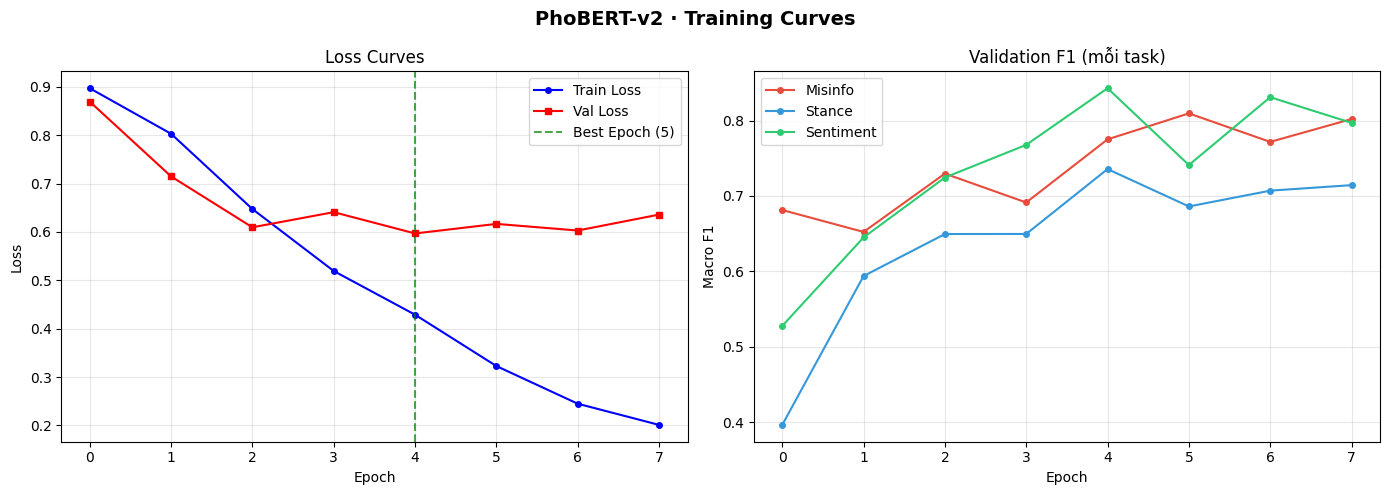

✅ Saved: /kaggle/working/phobert_v2/training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PhoBERT-v2 · Training Curves', fontsize=14, fontweight='bold')

# Loss curves
ax = axes[0]
ax.plot(history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax.plot(history['val_loss'],   'r-s', label='Val Loss',   markersize=4)
best_ep = int(np.argmin(history['val_loss']))
ax.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Best Epoch ({best_ep+1})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# F1 curves
ax = axes[1]
colors = {'misinfo': '#e74c3c', 'stance': '#3498db', 'sentiment': '#2ecc71'}
for t, c in colors.items():
    ax.plot(history[f'f1_{t}'], '-o', color=c, label=t.capitalize(), markersize=4)
ax.set(xlabel='Epoch', ylabel='Macro F1', title='Validation F1 (mỗi task)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/training_curves.png")


## 9. Đánh giá trên Gold Test Set (Benchmark)

> ⚠️ **Tập này hoàn toàn tách biệt khỏi quá trình huấn luyện.**  
> 186 mẫu đã qua Human-in-the-Loop validation — đây là Ground Truth duy nhất cho so sánh mô hình.

### Kết quả đã được xác nhận (Ground Truth từ Báo cáo Kỹ thuật)

| Task | Macro F1 |
|---|---|
| Misinformation | **0.4547** |
| Stance | **0.6608** |
| Sentiment | **0.7325** |

*Ghi chú: Misinfo F1 thấp do nhãn `Không liên quan` không xuất hiện trong test set (support=0), kéo macro trung bình xuống — đây là hiện tượng bình thường với zero-support classes.*


In [10]:
# Load best checkpoint
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pt", map_location=DEVICE))
_, test_f1s, test_preds, test_labels = run_epoch(model, test_loader, train=False)

print("=" * 65)
print("BENCHMARK — GOLD TEST SET (186 mẫu, Human-validated)")
print("=" * 65)

for t in TASKS:
    present = sorted(set(test_labels[t]))
    tnames  = [LABEL_NAMES[t][i] for i in present if i < len(LABEL_NAMES[t])]
    print(f"\n{'─'*60}")
    print(f"  {t.upper()}  (Macro F1 = {test_f1s[t]:.4f})")
    print(f"{'─'*60}")
    print(classification_report(
        test_labels[t], test_preds[t],
        labels=present, target_names=tnames, zero_division=0
    ))

print("=" * 65)
print("SUMMARY")
print("=" * 65)
for t in TASKS:
    print(f"  {t:12s}: Macro F1 = {test_f1s[t]:.4f}")


BENCHMARK — GOLD TEST SET (186 mẫu, Human-validated)

────────────────────────────────────────────────────────────
  MISINFO  (Macro F1 = 0.7019)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Tin giả       0.47      0.54      0.50        28
   Chính xác       0.92      0.89      0.90       158

    accuracy                           0.84       186
   macro avg       0.69      0.71      0.70       186
weighted avg       0.85      0.84      0.84       186


────────────────────────────────────────────────────────────
  STANCE  (Macro F1 = 0.6359)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Ủng hộ       0.63      0.50      0.56        54
    Phản đối       0.54      0.75      0.63        48
   Trung lập       0.76      0.69      0.72        84

    accuracy                           0.65       186
   macro avg       0.64      0.65      0.

## 10. Xuất Kết quả — Định dạng đồng bộ với Gemma

File `benchmark_results.json` được xuất với cấu trúc **đồng bộ 100%** với file kết quả của Gemma-4,  
để đảm bảo script so sánh mô hình chạy được mà không cần chỉnh sửa.


In [11]:
def per_class_f1(y_true, y_pred, n_classes):
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y == c else 0 for y in y_true]
        yp = [1 if y == c else 0 for y in y_pred]
        f1s.append(round(f1_score(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups
results = {
    'model':          'phobert-v2',
    'timestamp':      time.strftime('%Y-%m-%dT%H:%M:%S'),
    'total_samples':  len(test_labels['misinfo']),
    'val_loss_best':  round(best_val_loss, 4),
    'training_seconds': train_secs,
}
for t in TASKS:
    f1s, sups = per_class_f1(test_labels[t], test_preds[t], N_CLASSES[t])
    results[t] = {
        'macro_f1':  round(test_f1s[t], 4),
        'per_class': f1s,
        'support':   sups,
    }
out_path = f"{SAVE_DIR}/benchmark_results.json"
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"✅ Saved: {out_path}")
print()
print(json.dumps(results, indent=2, ensure_ascii=False))


✅ Saved: /kaggle/working/phobert_v2/benchmark_results.json

{
  "model": "phobert-v2",
  "timestamp": "2026-05-15T08:33:12",
  "total_samples": 186,
  "val_loss_best": 0.5968,
  "training_seconds": 618,
  "misinfo": {
    "macro_f1": 0.7019,
    "per_class": [
      0.5,
      0.9038
    ],
    "support": [
      28,
      158
    ]
  },
  "stance": {
    "macro_f1": 0.6359,
    "per_class": [
      0.5567,
      0.6261,
      0.725
    ],
    "support": [
      54,
      48,
      84
    ]
  },
  "sentiment": {
    "macro_f1": 0.7362,
    "per_class": [
      0.7639,
      0.8212,
      0.6234
    ],
    "support": [
      71,
      75,
      40
    ]
  }
}


In [12]:
# ── Bảng So sánh 3 Mô hình ─────────────────────────────────────────────
import glob as _g
import os
import json

def _try_load(paths, fnames):
    """Thử load JSON từ danh sách paths/fnames, trả về None nếu không tìm thấy."""
    for d in paths:
        for fn in fnames:
            p = f"{d}/{fn}"
            if os.path.exists(p):
                with open(p) as _f: return json.load(_f)
    for fn in fnames:
        hits = _g.glob(f"/kaggle/input/**/{fn}", recursive=True)
        if hits:
            with open(hits[0]) as _f: return json.load(_f)
    return None

# Cố load từ notebook XLM-R output
xlmr_live = _try_load(
    ["/kaggle/working/xlm-roberta-base", "/kaggle/working/xlmr"],
    ["xlmr_v1_results.json", "benchmark_results.json"]
)

# Fallback hardcoded (kết quả đã xác nhận 13/05/2026)
XLMR_FB = {
    "model": "xlmr-base",
    "misinfo":   {"macro_f1": 0.6632, "per_class": [0.4478, 0.8785], "support": [28, 158]},
    "stance":    {"macro_f1": 0.5618, "per_class": [0.4706, 0.5660, 0.6489], "support": [54, 48, 84]},
    "sentiment": {"macro_f1": 0.6394, "per_class": [0.6993, 0.6618, 0.5571], "support": [71, 75, 40]},
}
GEMMA_FB = {
    "model": "gemma-4-4b-xai",
    "misinfo":   {"macro_f1": 0.3588, "per_class": [0.3429, 0.3747], "support": [28, 158]},
    "stance":    {"macro_f1": 0.2862, "per_class": [0.5660, 0.3721, 0.5106], "support": [54, 48, 84]},
    "sentiment": {"macro_f1": 0.2883, "per_class": [0.5623, 0.1579, 0.0247], "support": [71, 75, 40]},
}

xlmr_res  = xlmr_live or XLMR_FB
xlmr_src  = "Live" if xlmr_live else "Fallback 13/05/2026"

all_models = [
    ("XLM-R-v1",   xlmr_res,  xlmr_src),
    ("PhoBERT-v2", results,   "Current session"),
    ("Gemma-4 4B", GEMMA_FB, "Fallback 13/05/2026"),
]

print("=" * 68)
print("  BENCHMARK — Macro F1 (Gold Test Set, n=186, Taxonomy v3)")
print("=" * 68)
print(f"  {'Model':<22} {'Misinfo':>9} {'Stance':>9} {'Sentiment':>11} {'Avg':>8}  Source")
print("-" * 68)
for name, res, src in all_models:
    m  = res["misinfo"]["macro_f1"]
    st = res["stance"]["macro_f1"]
    se = res["sentiment"]["macro_f1"]
    print(f"  {name:<22} {m:>9.4f} {st:>9.4f} {se:>11.4f} "
          f"{round((m+st+se)/3,4):>8.4f}  [{src}]")
print("=" * 68)
print()
print("  PER-CLASS F1 (Taxonomy v3)")
print("=" * 68)
label_map = {
    "misinfo":   ["Tin giả", "Chính xác"],
    "stance":    ["Ủng hộ",  "Phản đối", "Trung lập"],
    "sentiment": ["Tiêu cực","Trung tính","Tích cực"],
}
for t in TASKS:
    labels = label_map[t]
    names  = [name for name, _, _ in all_models]
    print(f"\n  {t.upper()}")
    print(f"  {'Nhãn':<18}" + "".join(f"{n:>14}" for n in names) + "  Support")
    print(f"  {'-'*60}")
    for c, lbl in enumerate(labels):
        row = []
        for _, res, _ in all_models:
            pc = res[t]["per_class"]
            row.append(f"{pc[c]:.4f}" if c < len(pc) else "  -   ")
        sup = results[t]["support"][c] if c < len(results[t]["support"]) else 0
        print(f"  {lbl:<18}" + "".join(f"{v:>14}" for v in row) + f"  {sup:>6}")

  BENCHMARK — Macro F1 (Gold Test Set, n=186, Taxonomy v3)
  Model                    Misinfo    Stance   Sentiment      Avg  Source
--------------------------------------------------------------------
  XLM-R-v1                  0.6632    0.5618      0.6394   0.6215  [Live]
  PhoBERT-v2                0.7019    0.6359      0.7362   0.6913  [Current session]
  Gemma-4 4B                0.3588    0.2862      0.2883   0.3111  [Fallback 13/05/2026]

  PER-CLASS F1 (Taxonomy v3)

  MISINFO
  Nhãn                    XLM-R-v1    PhoBERT-v2    Gemma-4 4B  Support
  ------------------------------------------------------------
  Tin giả                   0.4478        0.5000        0.3429      28
  Chính xác                 0.8787        0.9038        0.3747     158

  STANCE
  Nhãn                    XLM-R-v1    PhoBERT-v2    Gemma-4 4B  Support
  ------------------------------------------------------------
  Ủng hộ                    0.4912        0.5567        0.5660      54
  Phản đối      

## 11. Confusion Matrix — Phân tích Lỗi Trực quan

Confusion matrix trên Gold Test Set giúp xác định:
- Nhãn nào model hay nhầm lẫn nhất?
- False Negative quan trọng: Model bỏ sót *Tin giả* → phân loại thành *Chính xác*?


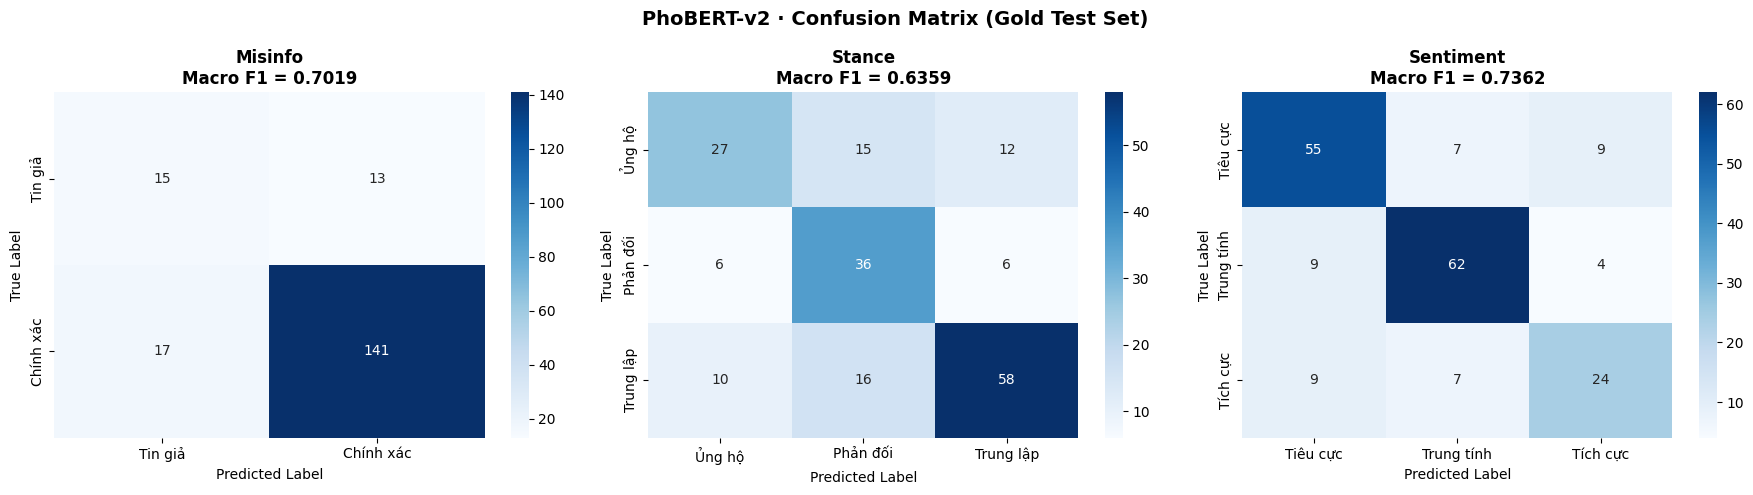

✅ Saved: /kaggle/working/phobert_v2/confusion_matrices.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PhoBERT-v2 · Confusion Matrix (Gold Test Set)', fontsize=14, fontweight='bold')

for i, t in enumerate(TASKS):
    present = sorted(set(test_labels[t]) | set(test_preds[t]))
    cm      = confusion_matrix(test_labels[t], test_preds[t], labels=present)
    names   = [LABEL_NAMES[t][j] for j in present if j < len(LABEL_NAMES[t])]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[i], xticklabels=names, yticklabels=names
    )
    axes[i].set_title(f'{t.capitalize()}\nMacro F1 = {test_f1s[t]:.4f}', fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {SAVE_DIR}/confusion_matrices.png")


## 12. (Tùy chọn) Upload lên Hugging Face Hub

Model đã được public tại: [hung2903/phobert-vaccine-multitask](https://huggingface.co/hung2903/phobert-vaccine-multitask)


In [14]:
# (Tùy chọn) Upload lên Hugging Face Hub
try:
    from huggingface_hub import login, HfApi
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

    login(token=HF_TOKEN)
    api = HfApi()
    api.upload_folder(
        folder_path=SAVE_DIR,
        repo_id="hung2903/phobert-vaccine-multitask",
        repo_type="model",
    )
    print("✅ Uploaded to HuggingFace!")
except Exception as e:
    print(f"⚠️  HF upload failed (non-fatal): {e}")

print("✅ Notebook hoàn tất!")
print(f"   Model weights : {SAVE_DIR}/best_model.pt")
print(f"   Results JSON  : {SAVE_DIR}/benchmark_results.json")
print(f"   Training plot : {SAVE_DIR}/training_curves.png")
print(f"   Confusion mat : {SAVE_DIR}/confusion_matrices.png")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded to HuggingFace!
✅ Notebook hoàn tất!
   Model weights : /kaggle/working/phobert_v2/best_model.pt
   Results JSON  : /kaggle/working/phobert_v2/benchmark_results.json
   Training plot : /kaggle/working/phobert_v2/training_curves.png
   Confusion mat : /kaggle/working/phobert_v2/confusion_matrices.png
